In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [15]:
x = np.random.randint(-40,40,size=(1000,2))
y = np.reshape([i[0]*3+i[1]*4 for i in x],shape=(-1,1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [16]:
model = Sequential([
    
    Dense(4, activation='sigmoid', input_shape=(2,)),
    Dense(1, activation='linear'),
])

# Compilação
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Resumo
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Treinamento
model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 12147.1299 - mae: 89.8771 - val_loss: 13658.7549 - val_mae: 96.5835
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12135.6523 - mae: 89.8357 - val_loss: 13644.5293 - val_mae: 96.5382
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12123.9805 - mae: 89.7953 - val_loss: 13630.6846 - val_mae: 96.4939
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12112.0957 - mae: 89.7534 - val_loss: 13617.4424 - val_mae: 96.4515
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12101.0830 - mae: 89.7142 - val_loss: 13604.7031 - val_mae: 96.4100
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12089.8896 - mae: 89.6744 - val_loss: 13593.7061 - val_mae: 96.3720
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12078.9072 - mae: 89.6351 - val_loss: 13583.0342 - val_mae: 96.3339
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12068.1553 - mae: 89.5963 - val_loss: 13572.3438 - 

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/stepWARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x761e4c312700> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


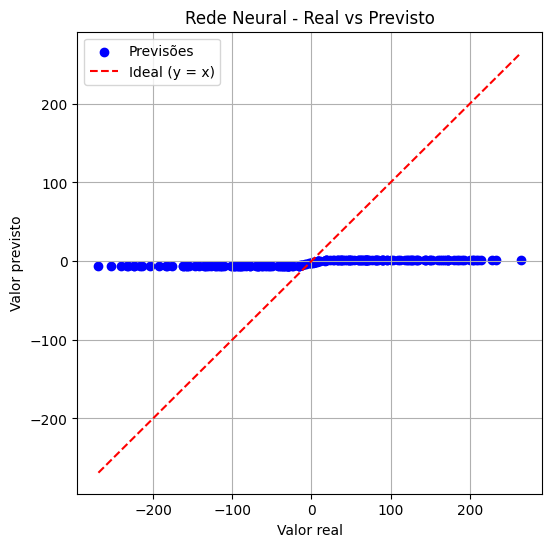

In [18]:
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', label='Previsões')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Ideal (y = x)'
)

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Rede Neural - Real vs Previsto")
plt.legend()
plt.grid()

plt.show()

In [19]:

model.predict(np.array([[1, 0.5]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[-0.94481075]], dtype=float32)

In [20]:
import numpy as np

weights = model.weights


# =====================================================
# FLOAT -> Q16.16
# =====================================================

FRAC = 16
SCALE = 1 << FRAC  # 65536

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)


def float_to_q16_16(value):
    """
    Converte float -> inteiro Q16.16

    Ex:
    1.0   -> 65536
    0.5   -> 32768
    -2.25 -> -147456
    """

    # NaN
    if np.isnan(value):
        return 0

    # +inf
    if np.isposinf(value):
        return INT32_MAX

    # -inf
    if np.isneginf(value):
        return INT32_MIN

    # conversão principal
    fixed = int(np.round(float(value) * SCALE))

    # saturação int32
    fixed = max(INT32_MIN, min(INT32_MAX, fixed))

    return fixed


def to_verilog_q16_16(val):
    """
    Formata para:

    32'sd65536
    -32'sd12345

    compatível com:
    logic signed [31:0]
    """

    fixed = float_to_q16_16(val)

    if fixed < 0:
        return f"-32'sd{abs(fixed)}"
    else:
        return f"32'sd{fixed}"


# =====================================================
# EXPORTAÇÃO
# =====================================================

with open("pesos_q16_16.txt", "w") as f:

    camada_idx = 1

    for var in weights:
        name = var.name
        data = var.numpy()

        tipo_raw = name.lower()

        if "kernel" in tipo_raw:
            tipo = "KERNEL"

        elif "bias" in tipo_raw:
            tipo = "BIAS"

        else:
            tipo = "UNKNOWN"

        # =================================================
        # KERNEL
        # =================================================

        if tipo == "KERNEL":

            # keras: (inputs, neurons)
            # verilog: [neuron][input]
            matriz = data.T

            n_neuronios, n_inputs = matriz.shape

            f.write("        // =====================================================\n")
            f.write(f"        // CAMADA {camada_idx} - PESOS\n")
            f.write(f"        // SHAPE ORIGINAL KERAS: {data.shape}\n")
            f.write("        // reorganizado para [neurônio][entrada]\n")
            f.write("        // formato: Q16.16 fixed-point\n")
            f.write("        // =====================================================\n\n")

            for neuronio in range(n_neuronios):

                f.write(f"        // neurônio {neuronio}\n")

                for entrada in range(n_inputs):

                    val = matriz[neuronio][entrada]
                    val_str = to_verilog_q16_16(val)

                    f.write(
                        f"        w{camada_idx}[{neuronio}][{entrada}] = {val_str};\n"
                    )

                f.write("\n")

        # =================================================
        # BIAS
        # =================================================

        elif tipo == "BIAS":

            f.write("        // =====================================================\n")
            f.write(f"        // CAMADA {camada_idx} - BIAS\n")
            f.write("        // formato: Q16.16 fixed-point\n")
            f.write("        // =====================================================\n\n")

            for i, v in enumerate(data):

                val_str = to_verilog_q16_16(v)

                f.write(
                    f"        b{camada_idx}[{i}] = {val_str};\n"
                )

            f.write("\n")

            # kernel + bias = mesma camada
            camada_idx += 1

print("Arquivo salvo: pesos_q16_16.txt")

Arquivo salvo: pesos_q16_16.txt


In [22]:
import numpy as np

weights = model.weights

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)

# =========================================
# FLOAT -> Q16.16
# =========================================
def float_to_q16(val):
    if np.isnan(val):
        return 0
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN

    fixed = int(np.round(val * SCALE))
    return max(INT32_MIN, min(INT32_MAX, fixed))

# =========================================
# ADDRESS (11 bits)
# =========================================
def build_addr(layer, is_bias, neuron, idx):
    return (layer << 9) | (is_bias << 8) | (neuron << 4) | idx

# =========================================
# EXPORT MEM
# =========================================
mem = {}

layer_idx = 0
i = 0

while i < len(weights):

    kernel = weights[i].numpy().T
    bias   = weights[i+1].numpy()

    n_neurons, n_inputs = kernel.shape

    # ===============================
    # PESOS
    # ===============================
    for n in range(n_neurons):
        for inp in range(n_inputs):

            if n >= 16 or inp >= 16:
                raise ValueError("Excedeu limite de 4 bits")

            addr = build_addr(layer_idx, 0, n, inp)
            mem[addr] = float_to_q16(kernel[n][inp])

    # ===============================
    # BIAS
    # ===============================
    for n in range(n_neurons):

        if n >= 16:
            raise ValueError("Excedeu limite de 4 bits")

        addr = build_addr(layer_idx, 1, n, 0)
        mem[addr] = float_to_q16(bias[n])

    layer_idx += 1
    i += 2

# =========================================
# WRITE FILE (.mem)
# =========================================
max_addr = max(mem.keys())

with open("weights.mem", "w") as f:
    for addr in range(max_addr + 1):
        val = mem.get(addr, 0)

        # two's complement se negativo
        if val < 0:
            val = (1 << 32) + val

        f.write(f"{val:08x}\n")

print("Arquivo salvo: weights.mem")

Arquivo salvo: weights.mem
